## Topic

Cross-Validation; Hyperparameter Tuning

先读[Machine Learning Foundations](../Study%20topics/ml-foundations-start-here.html)，再读对应[双语讲义](../Study%20topics/cross-validation-hyperparameter-tuning.html)。

## Question

What is Cross-Validation; Hyperparameter Tuning, and how would you evaluate it?

本实验中的模型或评估方法是什么？它解决什么问题，又怎样检验效果？

讲义提供Key Terms、直观例子、英文Short Answer及紧接其后的中文回答。先理解问题，再运行下面的代码。


# Cross-Validation; Hyperparameter Tuning

## Learning Goal

Cross-validation estimates variation across appropriate held-out folds. Hyperparameter search chooses a configuration using those folds. An outer test or nested evaluation is needed to estimate the selected procedure without selection optimism.

## Minimal Prerequisites

Basic Python arrays and functions. Run all cells in order; no API key or network data is required. Data are synthetic teaching fixtures, not empirical market evidence.

## Guided Experiment

Change alpha candidates and inspect fold-score variation. Explain why this shuffled K-fold example is not the workbench time-series validation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


    alpha   mean_MAE    fold_sd
0    0.01  17.401094   1.500349
1    1.00  17.484105   1.455233
2  100.00  60.599365  11.559835


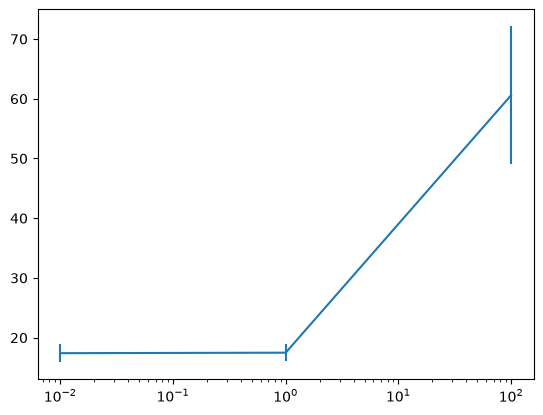

In [2]:
from sklearn.datasets import make_regression
from sklearn.model_selection import KFold,cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
X,y=make_regression(n_samples=200,n_features=20,noise=20,random_state=7);rows=[]
for alpha in [.01,1,100]:
    model=make_pipeline(StandardScaler(),Ridge(alpha=alpha))
    scores=-cross_val_score(model,X,y,cv=KFold(4,shuffle=True,random_state=7),scoring="neg_mean_absolute_error")
    rows.append([alpha,scores.mean(),scores.std()])
result=pd.DataFrame(rows,columns=["alpha","mean_MAE","fold_sd"]);print(result);plt.errorbar(result.alpha,result.mean_MAE,yerr=result.fold_sd);plt.xscale("log");plt.show()

## Expected Observations

Fold standard deviation is not automatically a confidence interval; folds share training observations. Keep search separate from final reporting.

## Review Experiment

Before changing a parameter, write the direction you expect and why. Change only the parameter named in the guided experiment; rerun from a fresh kernel. Compare the observed result with your prediction. On a later review day, explain the code without reading the answers.

## English Check Questions

1. What quantity is this experiment estimating?
2. What information is available at prediction time?
3. Which observation would invalidate your conclusion?

## Reference Answers

1. Cross-validation estimates variation across appropriate held-out folds. Hyperparameter search chooses a configuration using those folds. An outer test or nested evaluation is needed to estimate the selected procedure without selection optimism.
2. Training inputs and their labels must be available before the relevant evaluation origin; preprocessing is fitted on training data only.
3. Fold standard deviation is not automatically a confidence interval; folds share training observations. Keep search separate from final reporting.

## Financial Connection

Transfer the timing, metric or deployment contract to the five-day volatility Workbench. A toy experiment verifies mechanics, not trading profitability.

## Sources

- https://scikit-learn.org/stable/common_pitfalls.html
- https://scikit-learn.org/stable/modules/cross_validation.html
- https://scikit-learn.org/stable/modules/model_evaluation.html

[Return to study page](../Study%20topics/cross-validation-hyperparameter-tuning.html)
